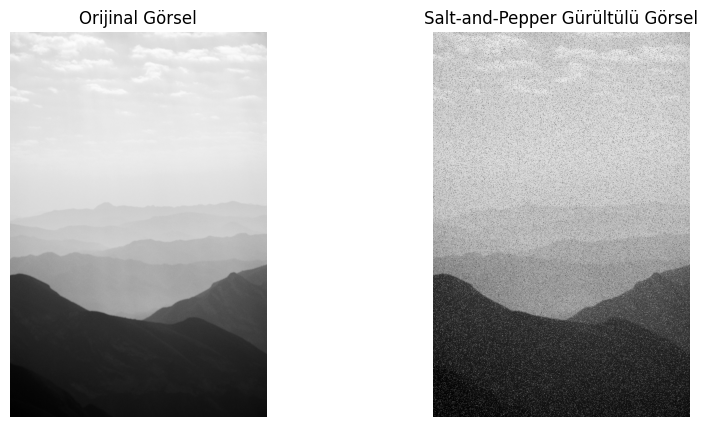

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def add_salt_and_pepper_noise(image, salt_prob, pepper_prob):
    noisy_image = image.copy()
    # Salt (Tuz) gürültüsü - Beyaz piksel
    num_salt = np.ceil(salt_prob * image.size)
    coords = [np.random.randint(0, i - 1, int(num_salt)) for i in image.shape]
    noisy_image[tuple(coords)] = 255

    # Pepper (Karabiber) gürültüsü - Siyah piksel
    num_pepper = np.ceil(pepper_prob * image.size)
    coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in image.shape]
    noisy_image[tuple(coords)] = 0
    return noisy_image

# Görseli gri tonlamalı (grayscale) olarak yükleyelim
img_path = '/content/resim1.jpeg'
original_img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

if original_img is None:
    # Eğer resim1.jpeg yüklenemezse boş bir görsel oluşturup gürültü ekleyelim
    original_img = np.ones((300, 300), dtype=np.uint8) * 128
    cv2.putText(original_img, 'Test', (50, 150), cv2.FONT_HERSHEY_SIMPLEX, 2, 0, 5)

# Salt-and-Pepper gürültüsü ekleme
noisy_img = add_salt_and_pepper_noise(original_img, 0.05, 0.05)

# Görselleri çizdirelim
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Orijinal Görsel")
plt.imshow(original_img, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Salt-and-Pepper Gürültülü Görsel")
plt.imshow(noisy_img, cmap='gray')
plt.axis('off')
plt.show()

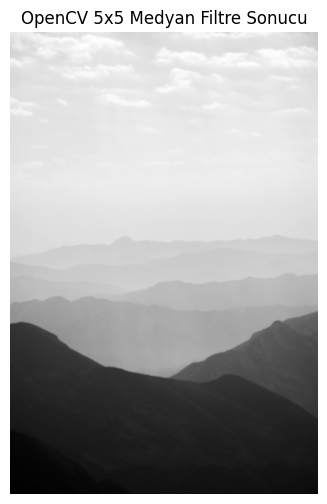

In [2]:
# OpenCV 5x5 Medyan Filtre uygulaması
opencv_median = cv2.medianBlur(noisy_img, 5)

plt.figure(figsize=(6, 6))
plt.title("OpenCV 5x5 Medyan Filtre Sonucu")
plt.imshow(opencv_median, cmap='gray')
plt.axis('off')
plt.show()

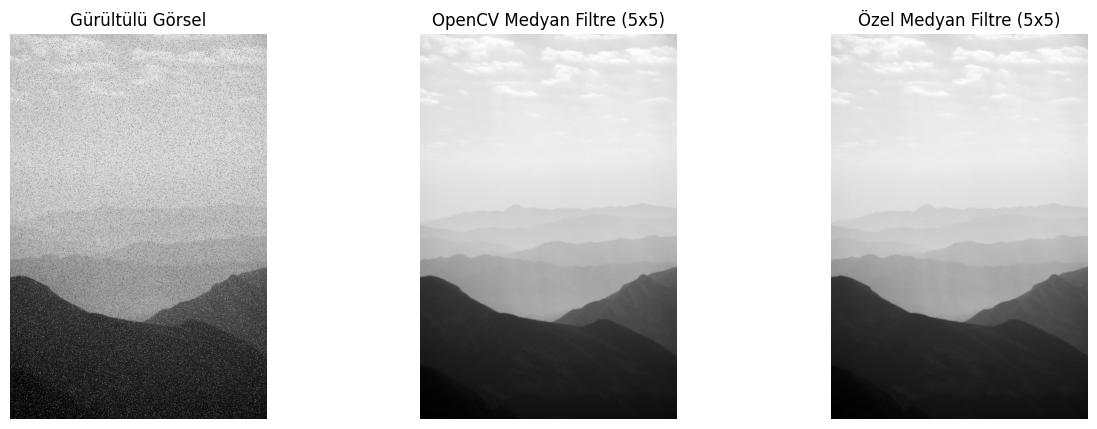

In [3]:
def custom_median_filter_5x5(image):
    # Görsel boyutlarını alalım
    H, W = image.shape
    # Çıkış görseli için boş bir dizi oluşturalım
    output_image = np.zeros((H, W), dtype=np.uint8)

    # 5x5 filtre için kenarlara 2 piksellik padding (dolgu) yapalım
    padded_image = np.pad(image, pad_width=2, mode='reflect')

    # Her piksel için 5x5 pencereyi dolaşalım
    for i in range(H):
        for j in range(W):
            # 5x5'lik komşuluk bölgesini alalım (padding uygulandığı için indis kayması yapılır)
            window = padded_image[i:i+5, j:j+5]
            # Penceredeki tüm değerleri sıralayıp ortanca (medyan) değeri bulalım
            median_value = np.median(window)
            output_image[i, j] = median_value

    return output_image

# Kendi yazdığımız fonksiyonu uygulayalım
custom_median = custom_median_filter_5x5(noisy_img)

# Sonuçları görselleştirelim
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title("Gürültülü Görsel")
plt.imshow(noisy_img, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("OpenCV Medyan Filtre (5x5)")
plt.imshow(opencv_median, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Özel Medyan Filtre (5x5)")
plt.imshow(custom_median, cmap='gray')
plt.axis('off')

plt.show()